# kT-RAM Neural Core — Memristor I-V Hysteresis (device characterization)

Drives a **single device model** (MSS or RS) with a sinusoidal voltage and plots current vs
voltage — the pinched hysteresis loop that defines a memristor (Chua: *if it's pinched, it's
a memristor*). Sweeping frequency changes the loop area, and the device-physics parameters
(`Ron`, `Roff`, `Von/Voff`, `tau`, `N`, `phi`, Schottky for MSS; `alpha`, rails for RS) are
the knobs you fit to a measured device.

This workbook talks to the device models **directly** (`device.drive(V, dt)` updates state,
`device.current(V)` reads current) — it does not go through the 2-1 synapse / instruction
set. It is for matching the model to real I-V data, not for synapse behavior.

### Frequency, timescale, and numerical validity
The loop's frequency dependence is governed by the dimensionless ratio of the per-step time
`dt` to the device timescale (`tau` for MSS; `1/alpha` scale for RS). The MSS switching
model requires `dt < tau` (its per-step probability is `dt/tau` — above 1 it is unphysical),
so we keep `dt = 1/(freq * steps_per_cycle)` well below `tau`. The requested 1 Hz-1 kHz range
therefore implies a device with `tau ~ 10 ms`; Knowm's fast devices (`tau ~ 10 us`) would be
characterized at kHz-MHz. **Set `tau`/`alpha` to your device and pick frequencies that
bracket its natural rate.**


In [1]:
%pip install -q ktram-neural-core numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ktram_neural_core.models.mss_model import MSSDevice, MSSProfile
from ktram_neural_core.models.rs_model import RSDevice
from ktram_neural_core.models.base import init_conductance

RNG = np.random.default_rng(0)

def iv_sweep(make_device, amplitude, freq, cycles=4, steps_per_cycle=2000):
    """Drive a fresh device with A*sin(2 pi f t); return (V, I) of the last (settled) cycle."""
    dev = make_device()
    dt = 1.0 / (freq * steps_per_cycle)
    n = cycles * steps_per_cycle
    t = np.arange(n) * dt
    V = amplitude * np.sin(2 * np.pi * freq * t)
    I = np.empty(n)
    for k, v in enumerate(V):
        dev.drive(float(v), dt)          # advance state over dt at voltage v
        I[k] = dev.current(float(v))     # current at v with the updated state
    last = slice((cycles - 1) * steps_per_cycle, n)
    return V[last], I[last], dt

def plot_loops(make_device, amplitude, freqs, title, tau_for_validity=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5.5))
    for f in freqs:
        V, I, dt = iv_sweep(make_device, amplitude, f)
        lbl = f'{f} Hz'
        if tau_for_validity:
            lbl += f'  (dt/tau={dt / tau_for_validity:.0e})'
        ax.plot(V, I * 1e3, lw=1.1, label=lbl)
    ax.axhline(0, color='0.85', lw=0.7); ax.axvline(0, color='0.85', lw=0.7)
    ax.set_xlabel('V (volts)'); ax.set_ylabel('I (mA)'); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, color='0.93')
    return ax

## 1. MSS pinched loop vs frequency  (ideal profile, phi=1)
`tau = 10 ms` so 1 Hz-1 kHz spans the transition. With `phi=1` and no Schottky the current
is `V * g(x)`; hysteresis arises purely because the state `x` (hence conductance) lags the
voltage. Loop area is largest at intermediate frequency and shrinks as f rises (too fast to
switch) or falls (quasi-static, fully switched each half-cycle).


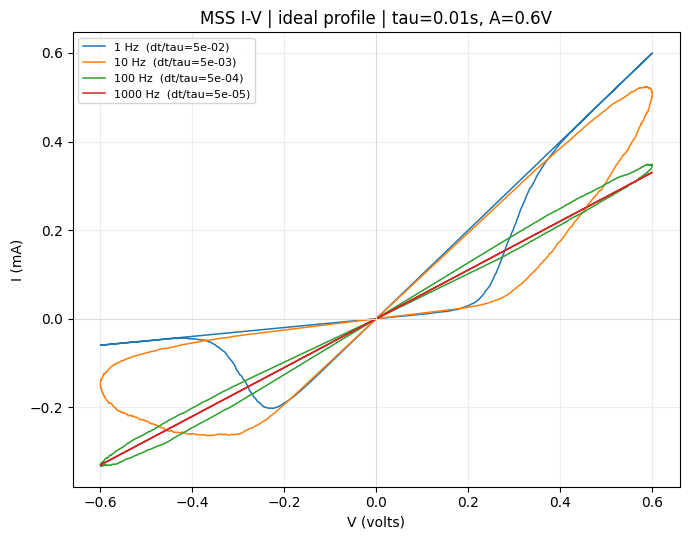

In [3]:
TAU = 1e-2
def mss_ideal():
    return MSSDevice.create(0.5, 0.0, RNG, MSSProfile(tau=TAU))
plot_loops(mss_ideal, amplitude=0.6, freqs=[1, 10, 100, 1000],
           title=f'MSS I-V | ideal profile | tau={TAU}s, A=0.6V', tau_for_validity=TAU)
plt.tight_layout(); plt.show()

## 2. RS pinched loop vs frequency  (deterministic)
RS has no `tau`; its rate is set by `alpha`. We use `alpha=200` so its switching lands in the
1 Hz-1 kHz window (the package default `alpha=1e6` is ~5000x faster — for the digital synapse,
not a slow I-V sweep). Deterministic, so the loops are clean.


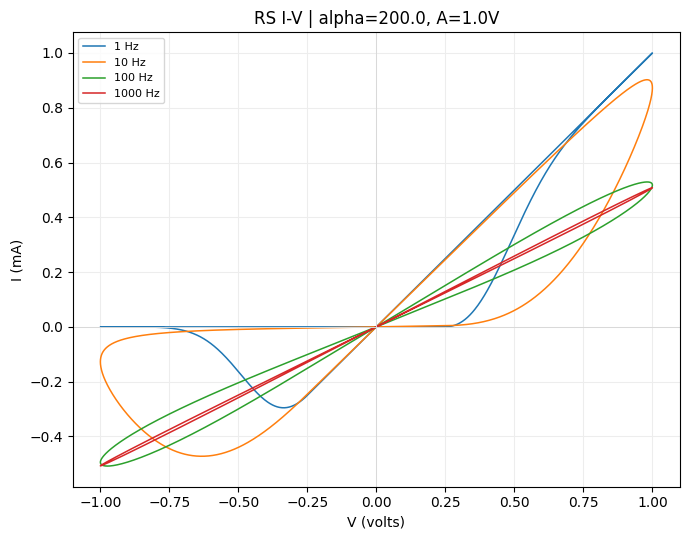

In [4]:
ALPHA = 200.0
def rs_demo():
    g0 = init_conductance(RSDevice.GMIN, RSDevice.GMAX, 0.5, 0.0, RNG)
    return RSDevice(g0, alpha=ALPHA)
plot_loops(rs_demo, amplitude=1.0, freqs=[1, 10, 100, 1000],
           title=f'RS I-V | alpha={ALPHA}, A=1.0V')
plt.tight_layout(); plt.show()

## 3. Curved loops via the Schottky term  (matching real devices)
Real Knowm I-V curves are not piecewise-linear — the current bends because part of it flows
through a Schottky barrier. Set `phi < 1` and the Schottky alphas/betas to add that nonlinear
component (`I = phi*V*g + (1-phi)*schottky(V)`). These four — `phi`, `schottky_fa/fb/ra/rb`
— plus `Ron/Roff` and `Von/Voff` are the primary fit handles against measured data.


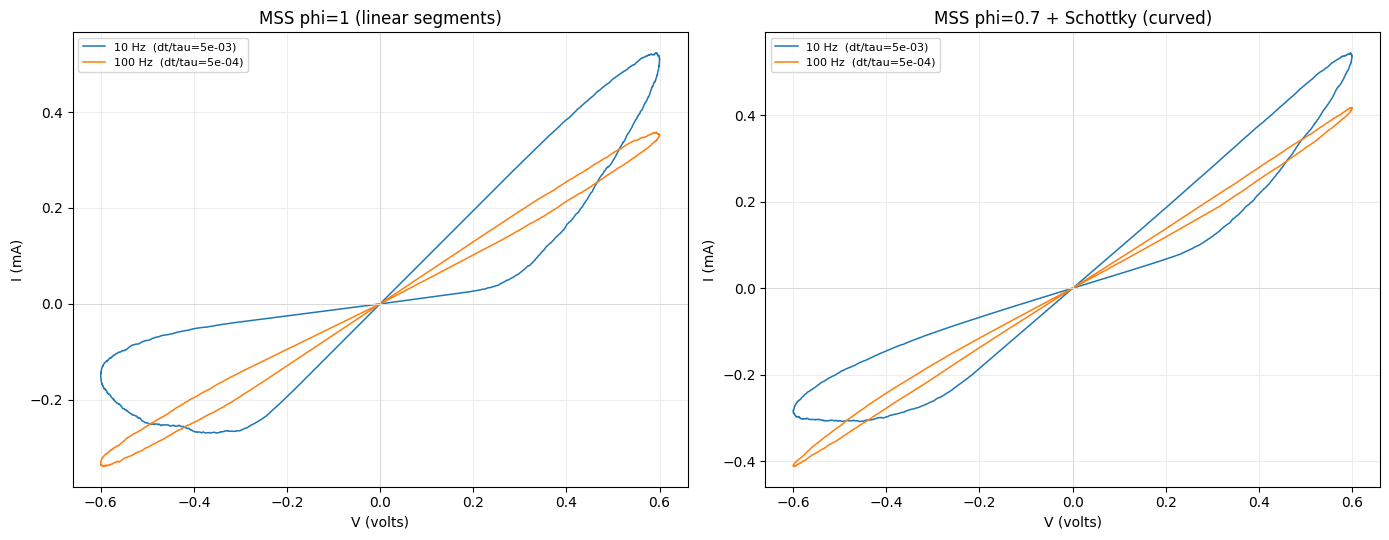

In [5]:
def mss_schottky():
    p = MSSProfile(tau=TAU, phi=0.7,
                   schottky_fa=2e-4, schottky_fb=2.0,
                   schottky_ra=2e-4, schottky_rb=2.0)
    return MSSDevice.create(0.5, 0.0, RNG, p)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
plot_loops(mss_ideal,    0.6, [10, 100], 'MSS phi=1 (linear segments)',  TAU, ax[0])
plot_loops(mss_schottky, 0.6, [10, 100], 'MSS phi=0.7 + Schottky (curved)', TAU, ax[1])
plt.tight_layout(); plt.show()

## 4. Parameter cheat-sheet for fitting

| Parameter | Sets | MSS | RS |
| --- | --- | :-: | :-: |
| `Ron`, `Roff` | conductance range (loop height) | yes | rails `GMin/GMax` |
| `Von`, `Voff` | threshold voltage (where it opens) | yes | dead-zone `Va/Vb` |
| `tau` / `alpha` | switching timescale (loop area vs freq) | `tau` | `alpha` |
| `N` | switch count -> intrinsic noise (loop jitter) | yes | n/a (deterministic) |
| `phi`, Schottky a/b | nonlinear current shape (loop curvature) | yes | n/a |

Workflow: fix `Ron/Roff` from the device's on/off conductance, `Von/Voff` from where the
loop opens, `tau`/`alpha` from the loop area at a known sweep frequency, then `phi` + Schottky
for the curvature, and `N` for the observed noise.
